<a href="https://colab.research.google.com/github/smuziVpyze/russian-market-news-analysis/blob/main/06_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = '/content/drive/MyDrive/russian_market_news_analysis'

TICKERS = ['MOEX', 'SBER', 'GAZP', 'LKOH', 'PLZL', 'YDEX']

datasets = {}
for ticker in TICKERS:
    df = pd.read_csv(f'{PROJECT_DIR}/data/features/{ticker}_features.csv')
    df['date'] = pd.to_datetime(df['date'])
    datasets[ticker] = df

print(f'✅ Загружено тикеров: {len(datasets)}')

Mounted at /content/drive
✅ Загружено тикеров: 6


In [2]:
# Признаки для моделей
MARKET_FEATURES = [
    'return_lag1', 'return_lag2', 'return_lag3',
    'return_2d', 'return_5d', 'volatility_5d', 'volatility_20d',
    'rsi', 'price_to_ma5', 'price_to_ma20', 'volume_ratio'
]

SENTIMENT_FEATURES = [
    'sentiment_mean', 'sentiment_net', 'sentiment_ma3', 'sentiment_ma7',
    'sentiment_mean_lag1', 'sentiment_net_lag1',
    'sentiment_mean_lag2', 'sentiment_net_lag2',
    'positive_ratio', 'negative_ratio',
    'positive_ratio_lag1', 'negative_ratio_lag1',
    'sentiment_change1', 'news_count'
]

def evaluate(y_true, y_pred, y_prob=None) -> dict:
    """Считаем все метрики качества."""
    metrics = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
    return metrics

def train_evaluate(ticker: str, features: list, model, model_name: str) -> dict:
    """Обучить модель с TimeSeriesSplit и вернуть метрики."""
    df = datasets[ticker].dropna(subset=features + ['target'])
    X = df[features].values
    y = df['target'].values

    # Временное разделение 80/20
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Масштабирование
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = evaluate(y_test, y_pred, y_prob)
    metrics.update({'ticker': ticker, 'model': model_name,
                    'train_size': len(X_train), 'test_size': len(X_test)})
    return metrics

# Baseline — всегда предсказываем рост
print('=== BASELINE (всегда рост) ===')
baseline_results = []
for ticker, df in datasets.items():
    split_idx = int(len(df) * 0.8)
    y_test = df['target'].values[split_idx:]
    y_pred = np.ones(len(y_test), dtype=int)
    m = evaluate(y_test, y_pred)
    m.update({'ticker': ticker, 'model': 'baseline'})
    baseline_results.append(m)
    print(f'{ticker}: accuracy={m["accuracy"]:.3f}, f1={m["f1"]:.3f}')

=== BASELINE (всегда рост) ===
MOEX: accuracy=0.421, f1=0.592
SBER: accuracy=0.467, f1=0.637
GAZP: accuracy=0.458, f1=0.628
LKOH: accuracy=0.383, f1=0.554
PLZL: accuracy=0.458, f1=0.628
YDEX: accuracy=0.490, f1=0.658


In [3]:
print('=== LOGISTIC REGRESSION (только рыночные признаки) ===')
lr_market_results = []
for ticker in TICKERS:
    m = train_evaluate(
        ticker=ticker,
        features=MARKET_FEATURES,
        model=LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'),
        model_name='lr_market'
    )
    lr_market_results.append(m)
    print(f'{ticker}: accuracy={m["accuracy"]:.3f}, f1={m["f1"]:.3f}, roc_auc={m["roc_auc"]:.3f}')

print('\n=== LOGISTIC REGRESSION (рыночные + сентимент) ===')
lr_full_results = []
for ticker in TICKERS:
    m = train_evaluate(
        ticker=ticker,
        features=MARKET_FEATURES + SENTIMENT_FEATURES,
        model=LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'),
        model_name='lr_full'
    )
    lr_full_results.append(m)
    print(f'{ticker}: accuracy={m["accuracy"]:.3f}, f1={m["f1"]:.3f}, roc_auc={m["roc_auc"]:.3f}')

=== LOGISTIC REGRESSION (только рыночные признаки) ===
MOEX: accuracy=0.505, f1=0.495, roc_auc=0.514
SBER: accuracy=0.449, f1=0.535, roc_auc=0.471
GAZP: accuracy=0.533, f1=0.500, roc_auc=0.567
LKOH: accuracy=0.477, f1=0.451, roc_auc=0.540
PLZL: accuracy=0.430, f1=0.430, roc_auc=0.444
YDEX: accuracy=0.480, f1=0.442, roc_auc=0.528

=== LOGISTIC REGRESSION (рыночные + сентимент) ===
MOEX: accuracy=0.477, f1=0.500, roc_auc=0.508
SBER: accuracy=0.411, f1=0.462, roc_auc=0.416
GAZP: accuracy=0.533, f1=0.490, roc_auc=0.558
LKOH: accuracy=0.495, f1=0.500, roc_auc=0.525
PLZL: accuracy=0.402, f1=0.360, roc_auc=0.436
YDEX: accuracy=0.549, f1=0.465, roc_auc=0.544


In [4]:
print('=== RANDOM FOREST (рыночные + сентимент) ===')
rf_results = []
for ticker in TICKERS:
    m = train_evaluate(
        ticker=ticker,
        features=MARKET_FEATURES + SENTIMENT_FEATURES,
        model=RandomForestClassifier(
            n_estimators=100, max_depth=10,
            min_samples_leaf=5, class_weight='balanced',
            random_state=42, n_jobs=-1
        ),
        model_name='random_forest'
    )
    rf_results.append(m)
    print(f'{ticker}: accuracy={m["accuracy"]:.3f}, f1={m["f1"]:.3f}, roc_auc={m["roc_auc"]:.3f}')

print('\n=== XGBOOST (рыночные + сентимент) ===')
xgb_results = []
for ticker in TICKERS:
    m = train_evaluate(
        ticker=ticker,
        features=MARKET_FEATURES + SENTIMENT_FEATURES,
        model=xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, eval_metric='logloss',
            verbosity=0
        ),
        model_name='xgboost'
    )
    xgb_results.append(m)
    print(f'{ticker}: accuracy={m["accuracy"]:.3f}, f1={m["f1"]:.3f}, roc_auc={m["roc_auc"]:.3f}')

=== RANDOM FOREST (рыночные + сентимент) ===
MOEX: accuracy=0.477, f1=0.541, roc_auc=0.519
SBER: accuracy=0.467, f1=0.529, roc_auc=0.432
GAZP: accuracy=0.495, f1=0.438, roc_auc=0.524
LKOH: accuracy=0.514, f1=0.519, roc_auc=0.543
PLZL: accuracy=0.486, f1=0.553, roc_auc=0.511
YDEX: accuracy=0.569, f1=0.569, roc_auc=0.574

=== XGBOOST (рыночные + сентимент) ===
MOEX: accuracy=0.458, f1=0.508, roc_auc=0.478
SBER: accuracy=0.486, f1=0.580, roc_auc=0.417
GAZP: accuracy=0.505, f1=0.465, roc_auc=0.543
LKOH: accuracy=0.477, f1=0.525, roc_auc=0.519
PLZL: accuracy=0.449, f1=0.496, roc_auc=0.452
YDEX: accuracy=0.608, f1=0.615, roc_auc=0.614


=== СВОДНАЯ ТАБЛИЦА ROC-AUC ===
        LR (рынок)  LR (рынок+сент)     RF  XGBoost
ticker                                             
GAZP         0.558            0.567  0.524    0.543
LKOH         0.525            0.540  0.543    0.519
MOEX         0.508            0.514  0.519    0.478
PLZL         0.436            0.444  0.511    0.452
SBER         0.416            0.471  0.432    0.417
YDEX         0.544            0.528  0.574    0.614


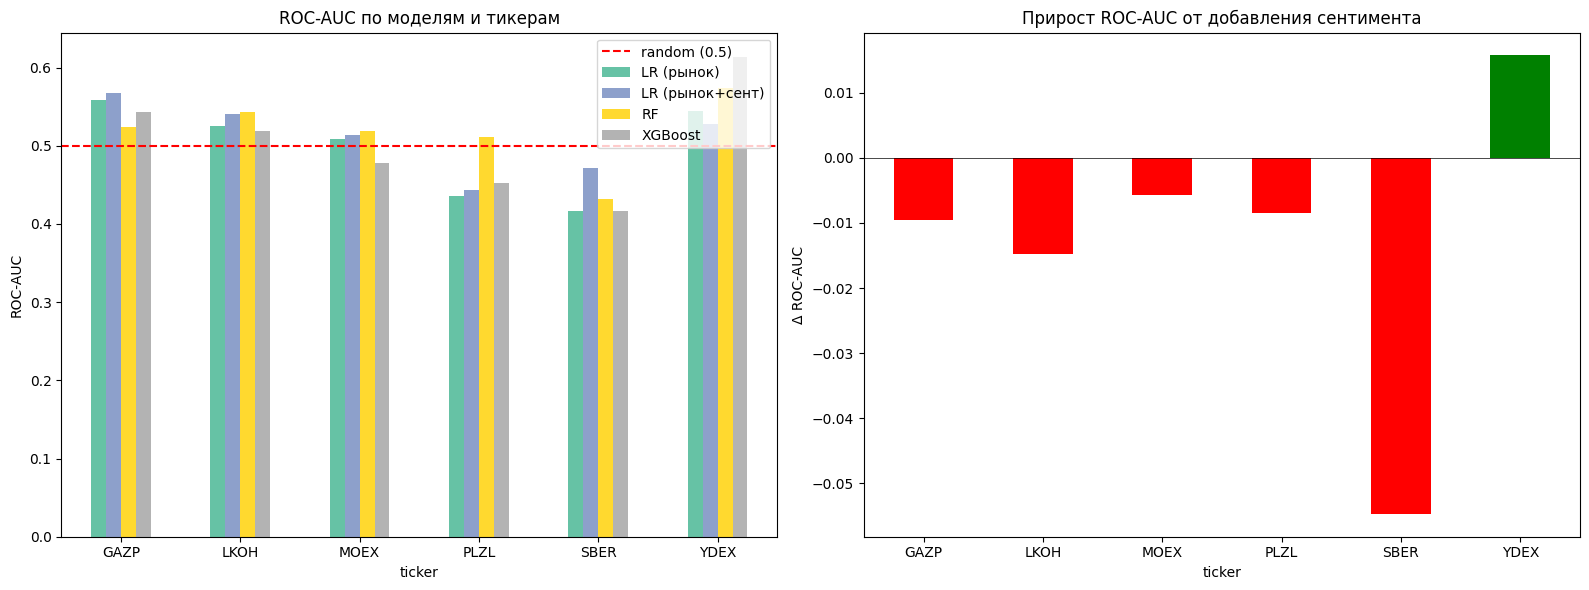


✅ Результаты сохранены


In [5]:
# Собираем все результаты
all_results = (baseline_results + lr_market_results +
               lr_full_results + rf_results + xgb_results)
df_results = pd.DataFrame(all_results)

# Сводная таблица по ROC-AUC
print('=== СВОДНАЯ ТАБЛИЦА ROC-AUC ===')
pivot = df_results[df_results['model'] != 'baseline'].pivot(
    index='ticker', columns='model', values='roc_auc'
).round(3)
pivot.columns = ['LR (рынок)', 'LR (рынок+сент)', 'RF', 'XGBoost']
print(pivot)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1 — ROC-AUC по моделям и тикерам
pivot.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].axhline(0.5, color='red', linestyle='--', label='random (0.5)')
axes[0].set_title('ROC-AUC по моделям и тикерам')
axes[0].set_ylabel('ROC-AUC')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

# График 2 — прирост от добавления сентимента (LR)
df_lr = df_results[df_results['model'].isin(['lr_market', 'lr_full'])]
pivot_lr = df_lr.pivot(index='ticker', columns='model', values='roc_auc')
pivot_lr['sentiment_gain'] = pivot_lr['lr_full'] - pivot_lr['lr_market']
colors = ['green' if x > 0 else 'red' for x in pivot_lr['sentiment_gain']]
pivot_lr['sentiment_gain'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Прирост ROC-AUC от добавления сентимента')
axes[1].set_ylabel('Δ ROC-AUC')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/model_comparison.png', dpi=150)
plt.show()

# Сохраняем результаты
df_results.to_csv(f'{PROJECT_DIR}/models/model_results.csv', index=False)
print('\n✅ Результаты сохранены')